# San Francisco Rent Board Housing Inventory
## Cleaning Comparisons and Bivariate Analysis

## Step 1 — Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## Step 2 — Load the dataset

In [ ]:
possible_files = [
    '/content/Rent_Board_Housing_Inventory_20261006.csv',
    '/content/Rent_Board_Housing_Inventory_20261004.csv',
    'Rent_Board_Housing_Inventory_20261006.csv',
    'Rent_Board_Housing_Inventory_20261004.csv'
]
DATA_PATH = next((p for p in possible_files if Path(p).exists()), possible_files[0])
df = pd.read_csv(DATA_PATH)
raw = df.copy()

print('Loaded:', DATA_PATH)
print('Original shape:', raw.shape)

Loaded: /content/Rent_Board_Housing_Inventory_20261006.csv
Original shape: (58442, 28)


## Step 3 — Inspect the original structure

In [ ]:
raw.info()
display(raw.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58442 entries, 0 to 58441
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   unique_id                            58442 non-null  int64  
 1   block_num                            58441 non-null  object 
 2   unit_count                           58442 non-null  float64
 3   case_type_name                       58442 non-null  object 
 4   submission_year                      58442 non-null  int64  
 5   block_address                        58435 non-null  object 
 6   occupancy_type                       58442 non-null  object 
 7   occupancy_or_vacancy_date            47353 non-null  object 
 8   occupancy_or_vacancy_date_year       50926 non-null  object 
 9   bedroom_count                        55143 non-null  object 
 10  bathroom_count                       55163 non-null  object 
 11  square_footage              

,unique_id,block_num,unit_count,case_type_name,submission_year,block_address,occupancy_type,occupancy_or_vacancy_date,occupancy_or_vacancy_date_year,bedroom_count,bathroom_count,square_footage,monthly_rent,base_rent_includes_water_sewer,base_rent_includes_natural_gas,base_rent_includes_electricity,base_rent_includes_refuse_recycling,base_rent_includes_other_utilities,past_occupancy,vacancy_date,signature_date,occupancy_or_vacancy_date_history,year_property_built,point,analysis_neighborhood,supervisor_district,data_as_of,data_loaded_at
0,-8888931167805846110,3180,173.0,Housing Inventory - Unit information (2023),2023,300 Block of BRIGHTON AVE,Occupied by non-owner,2021/06/14,2021,Two-Bedroom,Two bathrooms,1001-1250 Sq.Ft,$3751-$4000,N,N,N,N,NaN,No,NaN,2023/02/28,NaN,2012.0,POINT (-122.455200494 37.722760282),Oceanview/Merced/Ingleside,11.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
1,-8728105716412668324,3180,173.0,Housing Inventory - Unit information (2025),2025,300 Block of BRIGHTON AVE,Occupied by non-owner,2023/10/14,2023,One-Bedroom,One bathroom,751-1000 Sq.Ft,$3001-$3250,N,N,N,N,NaN,Yes,NaN,2025/02/23,"[\n {\n ""date_range_type"": ""Occupied"",\n ...",2012.0,POINT (-122.455062194 37.722760694),Oceanview/Merced/Ingleside,11.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
2,-8664205031566791701,0145,14.0,Housing Inventory - Unit information (2023),2023,0 Block of ROMOLO ST,Occupied by non-owner,1976/05/01,1976,One-Bedroom,One bathroom,501-750 Sq.Ft,$501-$750,Y,N,N,Y,NaN,No,NaN,2023/02/27,NaN,1907.0,POINT (-122.406233728 37.798263576),North Beach,3.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
3,-8198093964871002724,0285,70.0,Housing Inventory - Unit information (2023),2023,400 Block of STOCKTON ST,Occupied by non-owner,2022/12/15,2022,Studio,One bathroom,251-500 Sq.Ft,$1001-$1250,Y,N,N,Y,NaN,No,NaN,2023/02/24,NaN,1911.0,POINT (-122.407883607 37.793610704),Chinatown,3.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
4,-8126887673081079071,3180,173.0,Housing Inventory - Unit information (2022),2022,300 Block of BRIGHTON AVE,Occupied by non-owner,2021/07/25,2021,Two-Bedroom,Two bathrooms,1001-1250 Sq.Ft,$4001-$4250,N,N,N,N,NaN,Yes,NaN,2022/06/30,"[\n {\n ""end_date"": ""2021-05-22"",\n ""st...",2012.0,POINT (-122.455200494 37.722760282),Oceanview/Merced/Ingleside,11.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM


## Step 4 — Create the cleaning copy

In [ ]:
cleaned = raw.copy()
print('Cleaning copy created:', cleaned.shape)

Cleaning copy created: (58442, 28)


## Step 5 — Standardize missing values

In [ ]:
cleaned = cleaned.replace(
    ['Unknown', 'unknown', '', 'NULL', 'null', 'N/A', 'NA'],
    np.nan
)
print('Missing values standardized.')

Missing values standardized.


## Step 6 — Keep residential records

In [ ]:
residential_types = [
    'Occupied by non-owner',
    'Occupied by owner',
    'Vacant'
]

cleaned = cleaned[
    cleaned['occupancy_type'].isin(residential_types)
].copy()

print('Shape after residential filtering:', cleaned.shape)

Shape after residential filtering: (58179, 28)


## Step 7 — Check duplicates without using unique_id

In [ ]:
duplicate_mask = cleaned.drop(columns=['unique_id']).duplicated(keep=False)
print('Potential duplicate records:', duplicate_mask.sum())

# These rows are inspected, not automatically deleted.
display(cleaned.loc[duplicate_mask].head())

Potential duplicate records: 1940


,unique_id,block_num,unit_count,case_type_name,submission_year,block_address,occupancy_type,occupancy_or_vacancy_date,occupancy_or_vacancy_date_year,bedroom_count,bathroom_count,square_footage,monthly_rent,base_rent_includes_water_sewer,base_rent_includes_natural_gas,base_rent_includes_electricity,base_rent_includes_refuse_recycling,base_rent_includes_other_utilities,past_occupancy,vacancy_date,signature_date,occupancy_or_vacancy_date_history,year_property_built,point,analysis_neighborhood,supervisor_district,data_as_of,data_loaded_at
289,-9213064506919026041,7326,153.0,Housing Inventory - Unit information (2023),2023,100 Block of FONT BLVD,Vacant,NaN,2023,Two-Bedroom,Two bathrooms,1001-1250 Sq.Ft,NaN,N,N,N,N,NaN,No,NaN,2023/04/06,NaN,1949.0,POINT (-122.473629106 37.715544557),Lakeshore,7.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
290,-9213056276898226353,1793,6.0,Housing Inventory - Unit information (2025),2025,1300 Block of 38TH AVE,Occupied by non-owner,1998/12/31,1998,One-Bedroom,One bathroom,501-750 Sq.Ft,$751-$1000,N,N,N,N,NaN,No,NaN,2025/02/12,NaN,1951.0,POINT (-122.497487697 37.761730609),Sunset/Parkside,4.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
325,-9221528849370227871,3738,412.0,Housing Inventory - Unit information (2026),2026,200 Block of FREMONT ST,Occupied by non-owner,2020/08/25,2020,Studio,One bathroom,251-500 Sq.Ft,$2501-$2750,N,N,N,N,NaN,No,NaN,2026/02/23,NaN,2016.0,POINT (-122.393911345 37.78832457),Financial District/South Beach,6.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
333,-9219689874933393059,0343,116.0,Housing Inventory - Unit information (2024),2024,0 Block of TAYLOR ST,Occupied by non-owner,NaN,NaN,Studio,One bathroom,0-250 Sq.Ft,$501-$750,Y,N,N,Y,NaN,No,NaN,2024/02/29,NaN,1906.0,POINT (-122.410801053 37.783046322),Tenderloin,5.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
345,-9216822954593736805,3544,32.0,Housing Inventory - Unit information (2024),2024,2000 Block of MARKET ST,Vacant,NaN,NaN,Studio,One bathroom,251-500 Sq.Ft,NaN,N,N,N,N,NaN,No,NaN,2024/02/25,NaN,1914.0,POINT (-122.428694761 37.767530719),Castro/Upper Market,8.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM


## Step 8 — Convert numeric columns

In [ ]:
numeric_columns = ['unit_count', 'submission_year', 'year_property_built']

for col in numeric_columns:
    cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')

print(cleaned[numeric_columns].dtypes)

unit_count             float64
submission_year          int64
year_property_built    float64
dtype: object


## Step 9 — Convert date columns

In [ ]:
date_columns = [
    'occupancy_or_vacancy_date',
    'vacancy_date',
    'signature_date',
    'data_as_of',
    'data_loaded_at'
]

for col in date_columns:
    if col in cleaned.columns:
        cleaned[col] = pd.to_datetime(cleaned[col], errors='coerce')

print(cleaned['signature_date'].dtype)

datetime64[ns]


## Step 10 — Convert utility values to binary values

In [ ]:
utility_columns = [
    'base_rent_includes_water_sewer',
    'base_rent_includes_natural_gas',
    'base_rent_includes_electricity',
    'base_rent_includes_refuse_recycling',
    'base_rent_includes_other_utilities'
]

for col in utility_columns:
    if col in cleaned.columns:
        cleaned[col] = cleaned[col].map({'Y': 1, 'N': 0})

print('Utility columns converted.')

Utility columns converted.


## Step 11 — Standardize bedroom categories

In [ ]:
def clean_bedroom(value):
    if pd.isna(value):
        return 'Missing'
    value = str(value).lower().strip()
    if 'studio' in value or value == '0': return 'Studio'
    if value in ['1', 'one-bedroom', 'one bedroom']: return '1 Bedroom'
    if value in ['2', 'two-bedroom', 'two bedroom']: return '2 Bedrooms'
    if value in ['3', 'three-bedroom', 'three bedroom']: return '3 Bedrooms'
    if value in ['4', 'four-bedroom', 'four bedroom']: return '4 Bedrooms'
    if value == '5+': return '5+ Bedrooms'
    return 'Other'

cleaned['bedroom_category'] = cleaned['bedroom_count'].apply(clean_bedroom)
print(cleaned['bedroom_category'].value_counts())

bedroom_category
1 Bedroom      22243
Studio         14961
2 Bedrooms     13675
3 Bedrooms      3254
Missing         3085
4 Bedrooms       743
5+ Bedrooms      188
Other             30
Name: count, dtype: int64


## Step 12 — Standardize bathroom categories

In [ ]:
def clean_bathroom(value):
    if pd.isna(value): return 'Missing'
    value = str(value).lower().strip()
    if 'shared' in value: return 'Shared'
    if 'one and a half' in value: return '1.5 Bathrooms'
    if 'two and a half' in value: return '2.5 Bathrooms'
    if 'three' in value or value == '3': return '3+ Bathrooms'
    if 'two' in value or value == '2': return '2 Bathrooms'
    if 'one' in value or value == '1': return '1 Bathroom'
    return 'Other'

cleaned['bathroom_category'] = cleaned['bathroom_count'].apply(clean_bathroom)
print(cleaned['bathroom_category'].value_counts())

bathroom_category
1 Bathroom       44225
2 Bathrooms       6519
Missing           3056
Shared            2185
1.5 Bathrooms     1205
3+ Bathrooms       506
2.5 Bathrooms      446
Other               37
Name: count, dtype: int64


## Step 13 — Create a midpoint conversion function

In [ ]:
def midpoint(value):
    if pd.isna(value):
        return np.nan
    numbers = [
        float(x.replace(',', ''))
        for x in re.findall(r'\d[\d,]*', str(value))
    ]
    if len(numbers) >= 2:
        return (numbers[0] + numbers[1]) / 2
    return np.nan

## Step 14 — Convert monthly rent to a numeric target

In [ ]:
cleaned['rent_midpoint'] = cleaned['monthly_rent'].apply(midpoint)
print(cleaned['rent_midpoint'].describe())

count    50516.000000
mean      2501.662998
std       1217.622298
min        125.500000
25%       1625.500000
50%       2375.500000
75%       3125.500000
max       6875.500000
Name: rent_midpoint, dtype: float64


## Step 15 — Convert square footage to a numeric feature

In [ ]:
cleaned['square_footage_midpoint'] = cleaned['square_footage'].apply(midpoint)
print(cleaned['square_footage_midpoint'].describe())

count    54131.000000
mean       721.456162
std        387.995486
min        125.000000
25%        375.500000
50%        625.500000
75%        875.500000
max       3875.500000
Name: square_footage_midpoint, dtype: float64


## Step 16 — Create property age

In [ ]:
cleaned.loc[
    (cleaned['year_property_built'] < 1800) |
    (cleaned['year_property_built'] > cleaned['submission_year']),
    'year_property_built'
] = np.nan

cleaned['property_age'] = (
    cleaned['submission_year'] - cleaned['year_property_built']
)

cleaned.loc[
    (cleaned['property_age'] < 0) |
    (cleaned['property_age'] > 300),
    'property_age'
] = np.nan

print(cleaned['property_age'].describe())

count    56504.000000
mean        83.661334
std         35.397596
min          1.000000
25%         60.000000
50%         98.000000
75%        113.000000
max        176.000000
Name: property_age, dtype: float64


## Step 17 — Create the bivariate analysis dataset

In [ ]:
eda = cleaned.dropna(subset=['rent_midpoint']).copy()

# Keep useful analysis fields and remove raw/redundant versions.
drop_for_analysis = [
    'monthly_rent', 'square_footage', 'bedroom_count',
    'bathroom_count', 'point', 'data_as_of', 'data_loaded_at',
    'occupancy_or_vacancy_date_history', 'base_rent_includes_other_utilities',
    'vacancy_date', 'occupancy_or_vacancy_date_year', 'year_property_built',
    'case_type_name', 'block_address'
]

eda_final = eda.drop(columns=drop_for_analysis, errors='ignore').copy()
print('Final analysis shape:', eda_final.shape)

Final analysis shape: (50516, 19)


## Step 18 — Final cleaning check

In [ ]:
eda_final.info()
print('Duplicate rows:', eda_final.duplicated().sum())
display(eda_final.head())

<class 'pandas.core.frame.DataFrame'>
Index: 50516 entries, 0 to 58440
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   unique_id                            50516 non-null  int64         
 1   block_num                            50516 non-null  object        
 2   unit_count                           50516 non-null  float64       
 3   submission_year                      50516 non-null  int64         
 4   occupancy_type                       50516 non-null  object        
 5   occupancy_or_vacancy_date            46617 non-null  datetime64[ns]
 6   base_rent_includes_water_sewer       50516 non-null  int64         
 7   base_rent_includes_natural_gas       50516 non-null  float64       
 8   base_rent_includes_electricity       50516 non-null  float64       
 9   base_rent_includes_refuse_recycling  50516 non-null  float64       
 10  past_occupancy 

,unique_id,block_num,unit_count,submission_year,occupancy_type,occupancy_or_vacancy_date,base_rent_includes_water_sewer,base_rent_includes_natural_gas,base_rent_includes_electricity,base_rent_includes_refuse_recycling,past_occupancy,signature_date,analysis_neighborhood,supervisor_district,bedroom_category,bathroom_category,rent_midpoint,square_footage_midpoint,property_age
0,-8888931167805846110,3180,173.0,2023,Occupied by non-owner,2021-06-14,0,0.0,0.0,0.0,No,2023-02-28,Oceanview/Merced/Ingleside,11.0,2 Bedrooms,2 Bathrooms,3875.5,1125.5,11.0
1,-8728105716412668324,3180,173.0,2025,Occupied by non-owner,2023-10-14,0,0.0,0.0,0.0,Yes,2025-02-23,Oceanview/Merced/Ingleside,11.0,1 Bedroom,1 Bathroom,3125.5,875.5,13.0
2,-8664205031566791701,0145,14.0,2023,Occupied by non-owner,1976-05-01,1,0.0,0.0,1.0,No,2023-02-27,North Beach,3.0,1 Bedroom,1 Bathroom,625.5,625.5,116.0
3,-8198093964871002724,0285,70.0,2023,Occupied by non-owner,2022-12-15,1,0.0,0.0,1.0,No,2023-02-24,Chinatown,3.0,Studio,1 Bathroom,1125.5,375.5,112.0
4,-8126887673081079071,3180,173.0,2022,Occupied by non-owner,2021-07-25,0,0.0,0.0,0.0,Yes,2022-06-30,Oceanview/Merced/Ingleside,11.0,2 Bedrooms,2 Bathrooms,4125.5,1125.5,10.0


# Cleaning Comparisons

## Cleaning Comparison 1 — Record counts

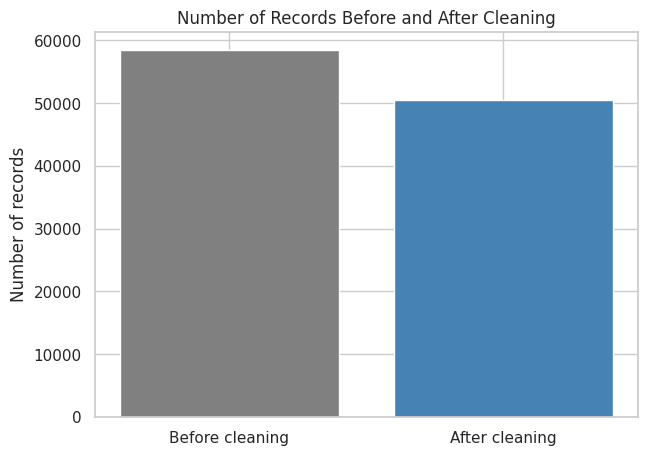

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(['Before cleaning', 'After cleaning'], [len(raw), len(eda_final)], color=['gray', 'steelblue'])
plt.title('Number of Records Before and After Cleaning')
plt.ylabel('Number of records')
plt.show()

## Cleaning Comparison 2 — Occupancy types

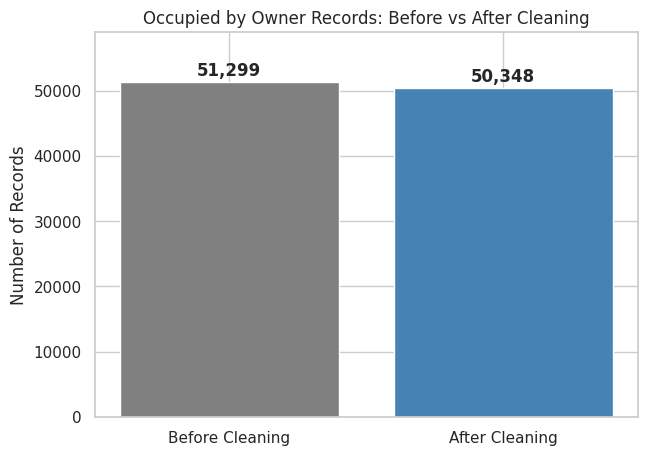

In [38]:
occupancy_type = "Occupied by non-owner"

before_count = (
    raw["occupancy_type"] == occupancy_type
).sum()

after_count = (
    eda_final["occupancy_type"] == occupancy_type
).sum()

counts = [before_count, after_count]
labels = ["Before Cleaning", "After Cleaning"]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    counts,
    color=["gray", "steelblue"]
)

plt.ylim(0, before_count * 1.15)
plt.title("Occupied by Owner Records: Before vs After Cleaning")
plt.ylabel("Number of Records")

# Display values above bars, including zero
for bar, value in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + before_count * 0.02,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )

plt.show()

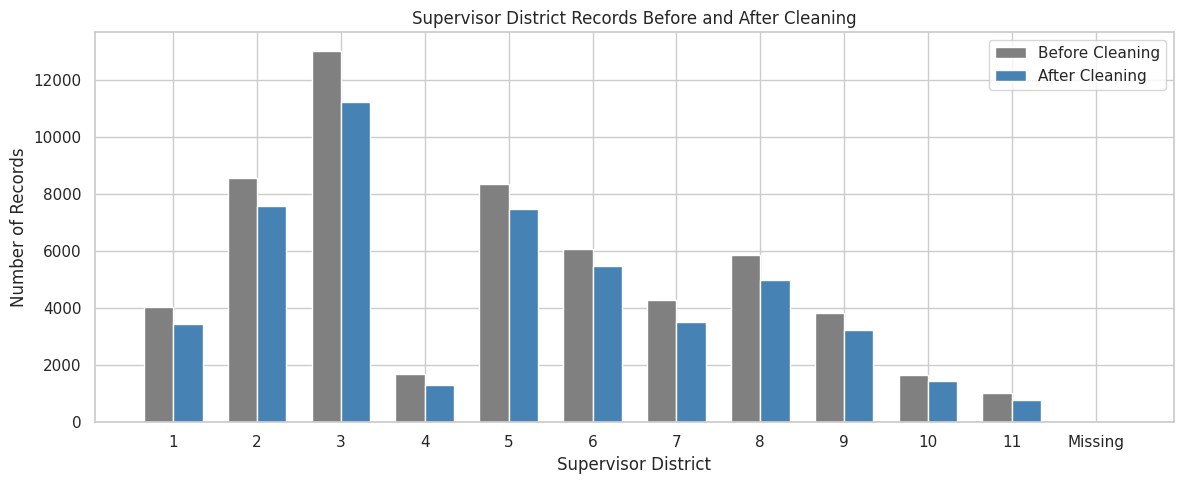

In [41]:
def clean_district_labels(series):
    return (
        pd.to_numeric(series, errors="coerce")
        .astype("Int64")
        .astype("string")
        .fillna("Missing")
    )

raw_district = clean_district_labels(
    raw["supervisor_district"]
).value_counts()

after_district = clean_district_labels(
    eda_final["supervisor_district"]
).value_counts()

district_labels = [
    str(i) for i in range(1, 12)
] + ["Missing"]

x = np.arange(len(district_labels))
width = 0.35

plt.figure(figsize=(12, 5))

plt.bar(
    x - width / 2,
    [raw_district.get(value, 0) for value in district_labels],
    width,
    label="Before Cleaning",
    color="gray"
)

plt.bar(
    x + width / 2,
    [after_district.get(value, 0) for value in district_labels],
    width,
    label="After Cleaning",
    color="steelblue"
)

plt.title("Supervisor District Records Before and After Cleaning")
plt.xlabel("Supervisor District")
plt.ylabel("Number of Records")
plt.xticks(x, district_labels)
plt.legend()
plt.tight_layout()
plt.show()

## Cleaning Comparison 3 — Bedroom categories

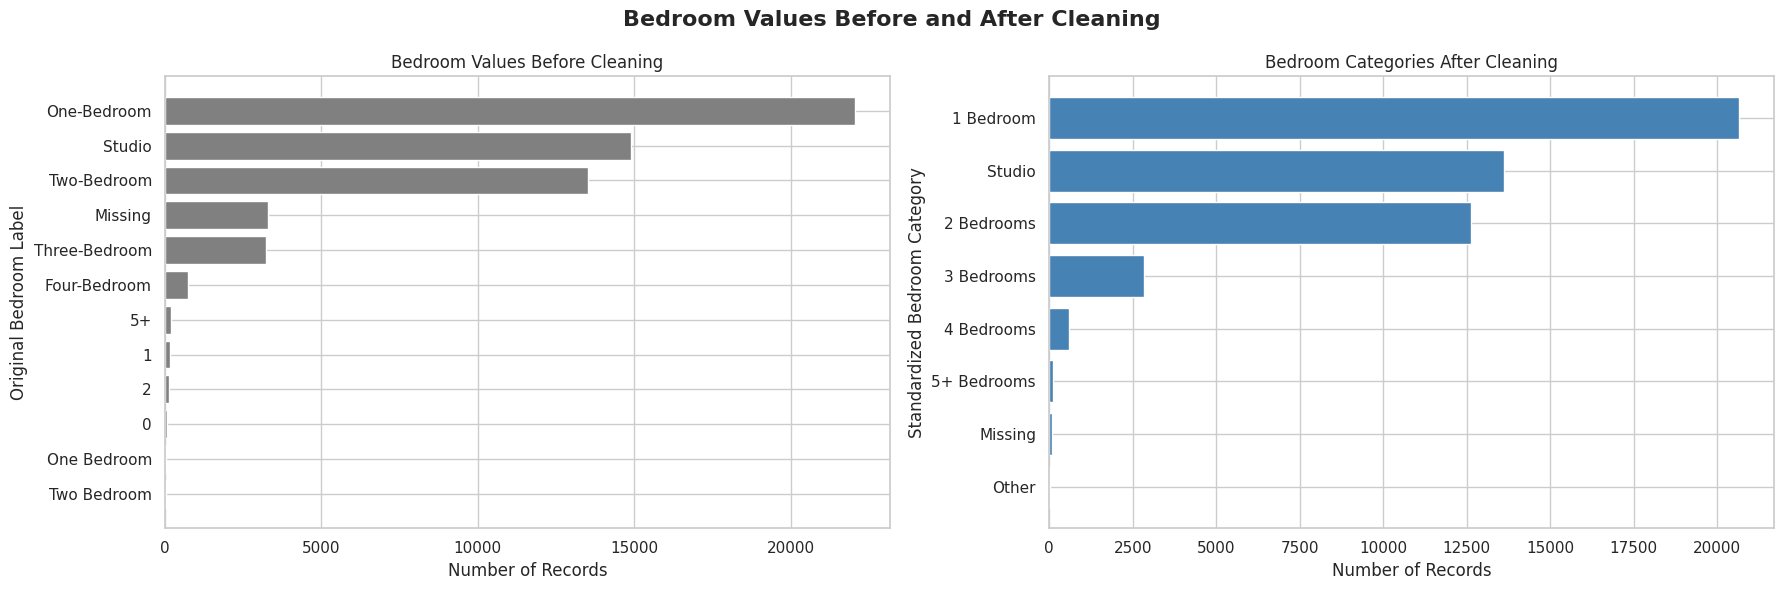

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Before cleaning: original bedroom labels
before_bedrooms = (
    raw["bedroom_count"]
    .fillna("Missing")
    .value_counts()
    .head(12)
    .sort_values()
)

axes[0].barh(
    before_bedrooms.index,
    before_bedrooms.values,
    color="gray"
)

axes[0].set_title("Bedroom Values Before Cleaning")
axes[0].set_xlabel("Number of Records")
axes[0].set_ylabel("Original Bedroom Label")

# After cleaning: standardized bedroom categories
after_bedrooms = (
    eda_final["bedroom_category"]
    .value_counts()
    .sort_values()
)

axes[1].barh(
    after_bedrooms.index,
    after_bedrooms.values,
    color="steelblue"
)

axes[1].set_title("Bedroom Categories After Cleaning")
axes[1].set_xlabel("Number of Records")
axes[1].set_ylabel("Standardized Bedroom Category")

plt.suptitle(
    "Bedroom Values Before and After Cleaning",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Cleaning comparison interpretation

The cleaning process restricted the analysis to residential records, removed records without a rent target, and standardized inconsistent bedroom labels. Values such as `One-Bedroom` and `1` were grouped together, while unclear codes such as `1U` and `2U` were placed in `Other`. The cleaned dataset is therefore more consistent for comparing rent across housing groups.

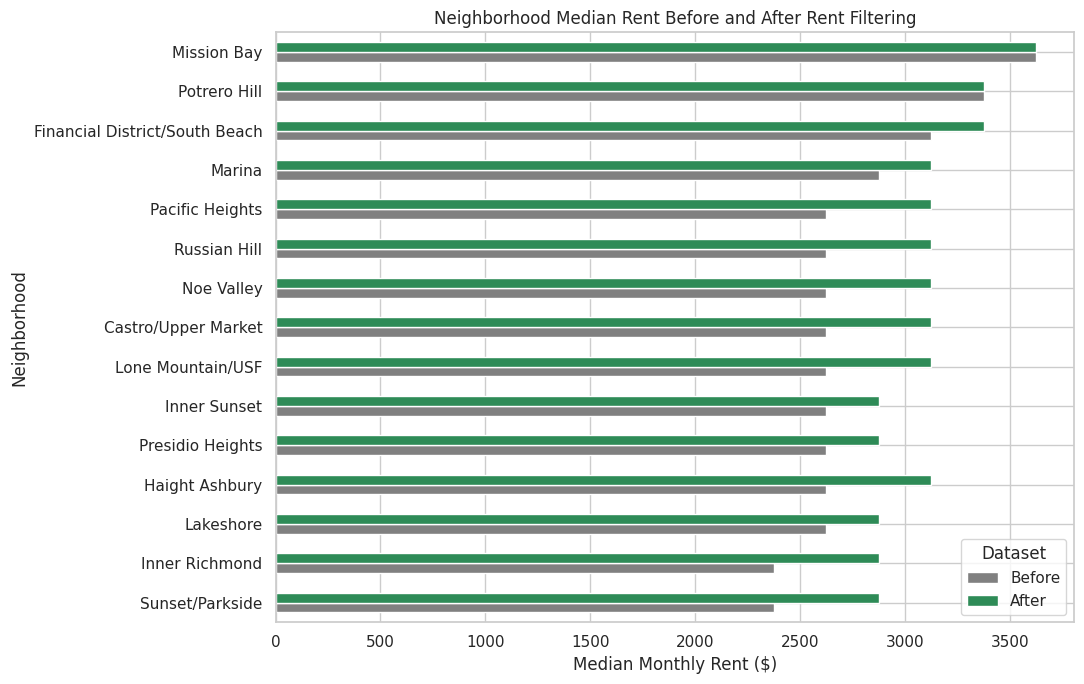

In [70]:
# Before filtering
before_summary = (
    eda_final
    .groupby("analysis_neighborhood")["rent_midpoint"]
    .agg(record_count="count", median_rent="median")
)

# After applying rent >= $2,000
rent_data = eda_final[
    eda_final["rent_midpoint"] >= 2000
].copy()

after_summary = (
    rent_data
    .groupby("analysis_neighborhood")["rent_midpoint"]
    .agg(record_count="count", median_rent="median")
)

# Select neighborhoods with at least 500 records before cleaning
top_neighborhoods = (
    before_summary
    .query("record_count >= 500")
    .sort_values("median_rent", ascending=False)
    .head(15)
    .sort_values("median_rent")
    .index
)

# Create comparison table
comparison = pd.DataFrame({
    "Before": before_summary.loc[top_neighborhoods, "median_rent"],
    "After": after_summary.reindex(top_neighborhoods)["median_rent"]
})

# Plot before and after
comparison.plot(
    kind="barh",
    figsize=(11, 7),
    color=["gray", "seagreen"]
)

plt.title("Neighborhood Median Rent Before and After Rent Filtering")
plt.xlabel("Median Monthly Rent ($)")
plt.ylabel("Neighborhood")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# Bivariate Analysis

### Bivariate Analysis 1 — Rent and square footage

**Research question:** Do larger housing units generally have higher monthly rent?

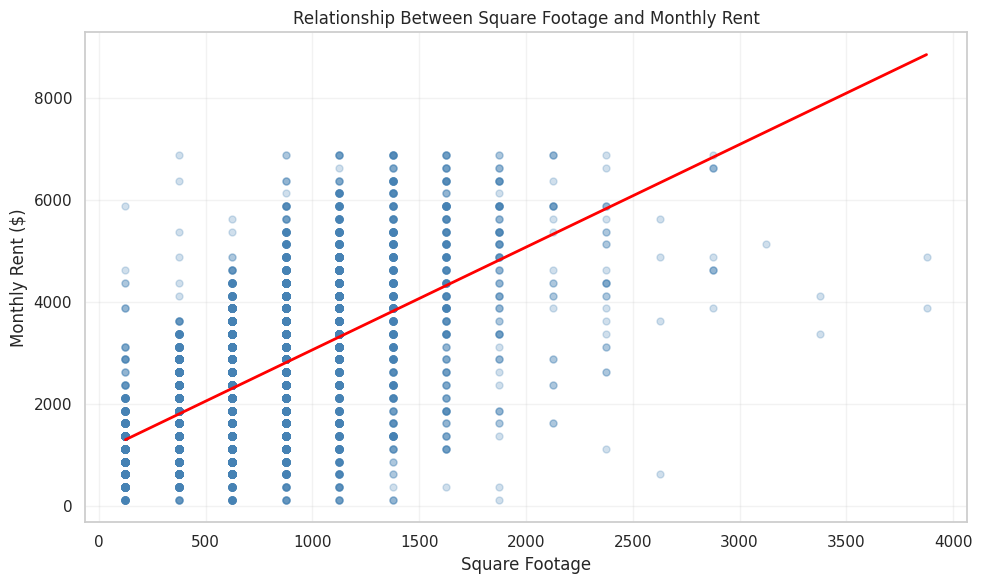

In [44]:
# Select valid values
scatter_data = eda_final.dropna(
    subset=["square_footage_midpoint", "rent_midpoint"]
).sample(
    n=min(10000, len(eda_final.dropna(
        subset=["square_footage_midpoint", "rent_midpoint"]
    ))),
    random_state=42
)

# Scatter plot with trend line
plt.figure(figsize=(10, 6))

sns.regplot(
    data=scatter_data,
    x="square_footage_midpoint",
    y="rent_midpoint",
    scatter_kws={
        "alpha": 0.25,
        "color": "steelblue",
        "s": 25
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    },
    ci=None
)

plt.title("Relationship Between Square Footage and Monthly Rent")
plt.xlabel("Square Footage")
plt.ylabel("Monthly Rent ($)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The scatter plot examines whether square footage is related to monthly rent. The red trend line shows the overall direction of the relationship. If the line slopes upward, larger housing units generally have higher monthly rents. The spread of points indicates that square footage is not the only factor affecting rent.

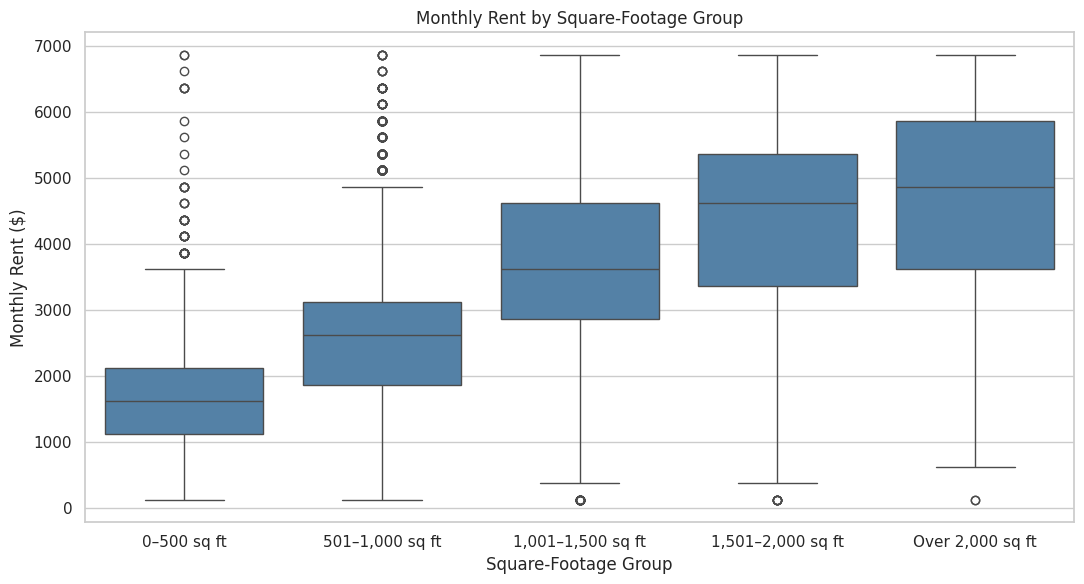

In [56]:
# Select valid numeric values
plot_data = eda_final.dropna(
    subset=["square_footage_midpoint", "rent_midpoint"]
).copy()

# Create square-footage groups
plot_data["square_footage_group"] = pd.cut(
    plot_data["square_footage_midpoint"],
    bins=[0, 500, 1000, 1500, 2000, float("inf")],
    labels=[
        "0–500 sq ft",
        "501–1,000 sq ft",
        "1,001–1,500 sq ft",
        "1,501–2,000 sq ft",
        "Over 2,000 sq ft"
    ]
)

# Create boxplot
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=plot_data,
    x="square_footage_group",
    y="rent_midpoint",
    color="steelblue"
)

plt.title("Monthly Rent by Square-Footage Group")
plt.xlabel("Square-Footage Group")
plt.ylabel("Monthly Rent ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# HANDLING OUTLIERS

### 1. Check impossible values

In [57]:
# Check impossible values
print("Square footage <= 0:",
      (eda_final["square_footage_midpoint"] <= 0).sum())

print("Rent <= 0:",
      (eda_final["rent_midpoint"] <= 0).sum())

Square footage <= 0: 0
Rent <= 0: 0


### Remove

In [58]:
eda_final = eda_final[
    (eda_final["square_footage_midpoint"] > 0) &
    (eda_final["rent_midpoint"] > 0)
].copy()

### Identify statistical outliers using IQR

In [59]:
def iqr_limits(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    return lower_limit, upper_limit

rent_lower, rent_upper = iqr_limits(
    eda_final["rent_midpoint"]
)

sqft_lower, sqft_upper = iqr_limits(
    eda_final["square_footage_midpoint"]
)

print("Rent limits:", rent_lower, rent_upper)
print("Square-footage limits:", sqft_lower, sqft_upper)

Rent limits: -624.5 5375.5
Square-footage limits: -374.5 1625.5


### 3. Count the outliers

In [60]:
rent_outliers = (
    (eda_final["rent_midpoint"] < rent_lower) |
    (eda_final["rent_midpoint"] > rent_upper)
)

sqft_outliers = (
    (eda_final["square_footage_midpoint"] < sqft_lower) |
    (eda_final["square_footage_midpoint"] > sqft_upper)
)

print("Rent outliers:", rent_outliers.sum())
print("Square-footage outliers:", sqft_outliers.sum())

Rent outliers: 1028
Square-footage outliers: 675


## Bivariate Analysis 1 — Statistic

In [ ]:
correlation = scatter_data[['square_footage_midpoint', 'rent_midpoint']].corr().iloc[0, 1]
print('Pearson correlation:', round(correlation, 3))

Pearson correlation: 0.598


## Bivariate Analysis 1 — Interpretation

If the points generally rise from left to right, there is a positive relationship: larger units tend to have higher rent. A wide spread around the pattern indicates that neighborhood, bedrooms, bathrooms, and other factors also influence rent. Correlation describes association and does not prove causation.

## Bivariate Analysis 2 — Rent and bedroom category

**Research question:** How does the distribution of monthly rent vary by bedroom category?

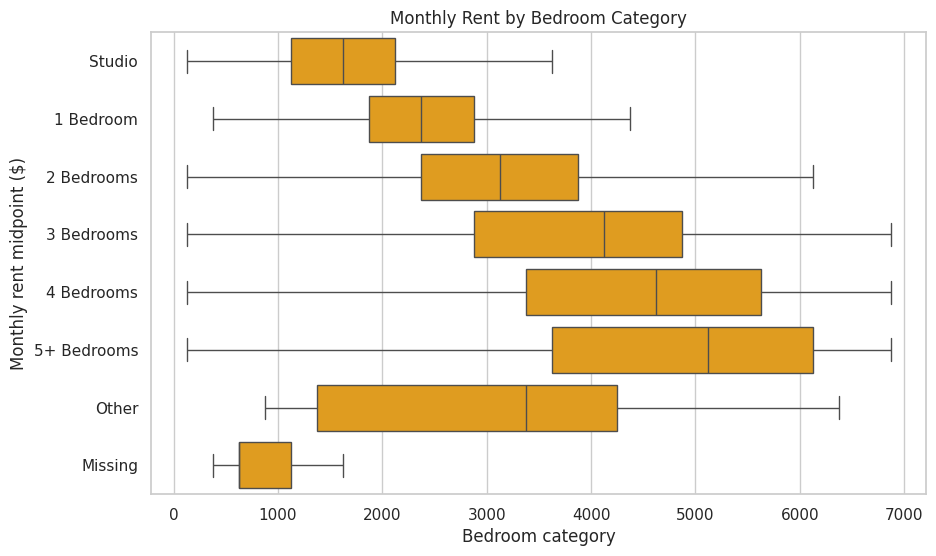

In [46]:
bedroom_order = ['Studio', '1 Bedroom', '2 Bedrooms', '3 Bedrooms', '4 Bedrooms', '5+ Bedrooms', 'Other', 'Missing']

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=eda_final,
    y='bedroom_category',
    x='rent_midpoint',
    order=bedroom_order,
    showfliers=False,
    color='orange'
)
plt.title('Monthly Rent by Bedroom Category')
plt.xlabel('Bedroom category')
plt.ylabel('Monthly rent midpoint ($)')
plt.xticks(rotation=0)
plt.show()

## Bivariate Analysis 2 — Statistic

In [ ]:
bedroom_summary = (
    eda_final.groupby('bedroom_category')['rent_midpoint']
    .agg(record_count='count', median_rent='median', mean_rent='mean')
    .sort_values('median_rent', ascending=False)
)
display(bedroom_summary)

,record_count,median_rent,mean_rent
bedroom_category,,,
5+ Bedrooms,106,5125.5,4651.443396
4 Bedrooms,582,4625.5,4321.805842
3 Bedrooms,2826,4125.5,3905.047063
Other,19,3375.5,3178.131579
2 Bedrooms,12626,3125.5,3167.912482
1 Bedroom,20668,2375.5,2409.949390
Studio,13606,1625.5,1645.252315
Missing,83,625.5,932.728916


## Bivariate Analysis 2 — Interpretation

Compare the medians and the spread of the box plots. If median rent rises from studios to larger bedroom categories, bedroom count is associated with rent. Wider boxes indicate greater rent variation within that bedroom category.

## Bivariate Analysis 3 — Rent and neighborhood

**Research question:** Does monthly rent differ across San Francisco neighborhoods?

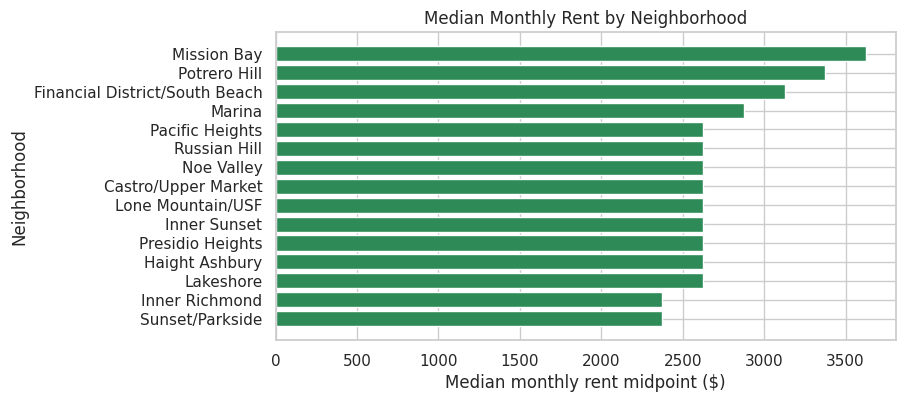

In [78]:
neighborhood_summary = (
    eda_final.groupby('analysis_neighborhood')['rent_midpoint']
    .agg(record_count='count', median_rent='median')
    .query('record_count >= 500')
    .sort_values('median_rent', ascending=False)
    .head(15)
    .sort_values('median_rent')
)

fig, ax = plt.subplots(figsize=(8, 4))
plt.barh(
    neighborhood_summary.index,
    neighborhood_summary['median_rent'],
    color='seagreen'
)
plt.title('Median Monthly Rent by Neighborhood')
plt.xlabel('Median monthly rent midpoint ($)')
plt.ylabel('Neighborhood')
plt.show()

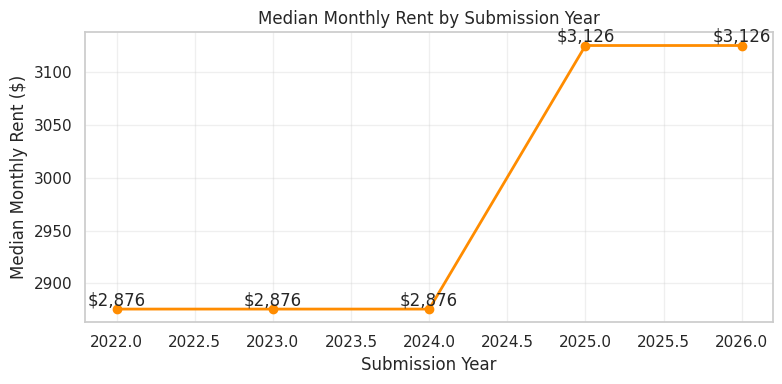

In [80]:
# Keep valid rent values
rent_data = eda_final[
    eda_final["rent_midpoint"] >= 2000
].copy()

# Calculate median rent by year
yearly_rent = (
    rent_data
    .groupby("submission_year")["rent_midpoint"]
    .median()
    .reset_index()
    .sort_values("submission_year")
)

# Create line chart
plt.figure(figsize=(8, 4))

plt.plot(
    yearly_rent["submission_year"],
    yearly_rent["rent_midpoint"],
    marker="o",
    linewidth=2,
    color="darkorange"
)

# Add values to points
for x, y in zip(
    yearly_rent["submission_year"],
    yearly_rent["rent_midpoint"]
):
    plt.text(
        x, y,
        f"${y:,.0f}",
        ha="center",
        va="bottom"
    )

plt.title("Median Monthly Rent by Submission Year")
plt.xlabel("Submission Year")
plt.ylabel("Median Monthly Rent ($)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

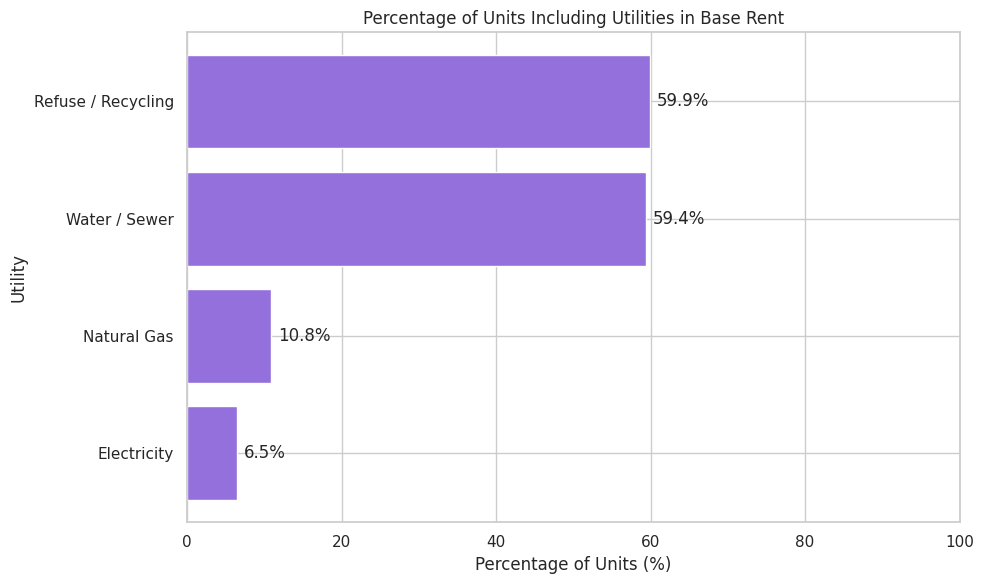

In [81]:
utility_columns = {
    "Water / Sewer": "base_rent_includes_water_sewer",
    "Natural Gas": "base_rent_includes_natural_gas",
    "Electricity": "base_rent_includes_electricity",
    "Refuse / Recycling": "base_rent_includes_refuse_recycling"
}

# Calculate percentage included
utility_percent = (
    eda_final[list(utility_columns.values())]
    .mean()
    .mul(100)
    .rename(index={
        column: label
        for label, column in utility_columns.items()
    })
    .sort_values()
)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    utility_percent.index,
    utility_percent.values,
    color="mediumpurple"
)

# Add percentage labels
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in utility_percent.values],
    padding=5
)

ax.set_title("Percentage of Units Including Utilities in Base Rent")
ax.set_xlabel("Percentage of Units (%)")
ax.set_ylabel("Utility")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

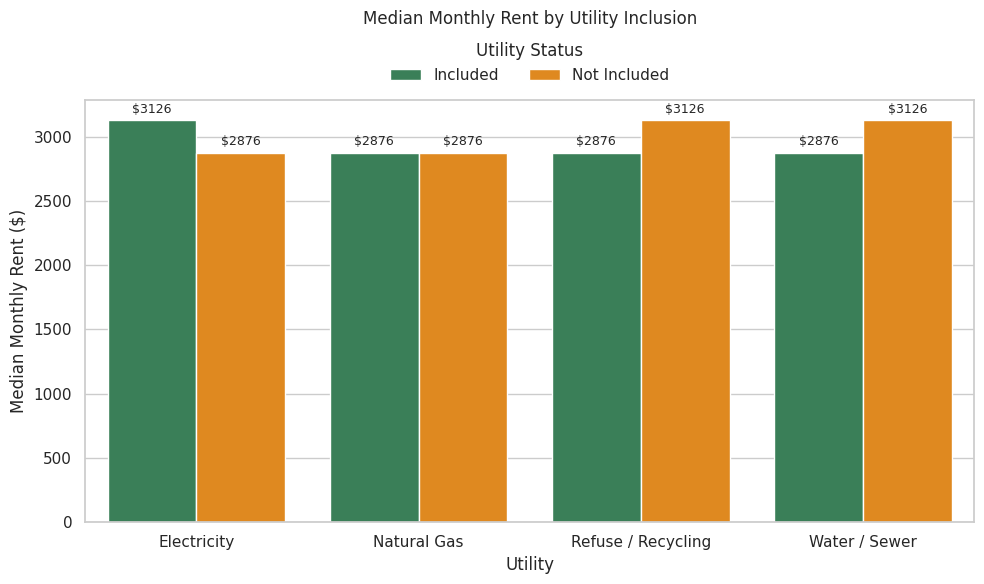

In [93]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=utility_rent_summary,
    x="Utility",
    y="rent_midpoint",
    hue="Utility Status",
    palette={
        "Included": "seagreen",
        "Not Included": "darkorange"
    },
    errorbar=None,
    ax=ax
)

# Add exact rent values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="$%.0f",
        fontsize=9,
        padding=3
    )

ax.set_title("Median Monthly Rent by Utility Inclusion", pad=55)
ax.set_xlabel("Utility")
ax.set_ylabel("Median Monthly Rent ($)")

# Place legend above the graph
ax.legend(
    title="Utility Status",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.17),
    ncol=2,
    frameon=False
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Bivariate Analysis 3 — Statistic

In [ ]:
display(neighborhood_summary.sort_values('median_rent', ascending=False))

,record_count,median_rent
analysis_neighborhood,,
Mission Bay,1368,3625.5
Potrero Hill,843,3375.5
Financial District/South Beach,2255,3125.5
Marina,3014,2875.5
Lakeshore,1931,2625.5
Presidio Heights,654,2625.5
Haight Ashbury,1321,2625.5
Pacific Heights,2957,2625.5
Russian Hill,2236,2625.5


## Bivariate Analysis 3 — Interpretation

The bar chart compares median rent across neighborhoods. Large differences between neighborhoods suggest that location is associated with rent. Neighborhoods with fewer than 500 records were excluded from this comparison so that very small groups do not dominate the conclusion.

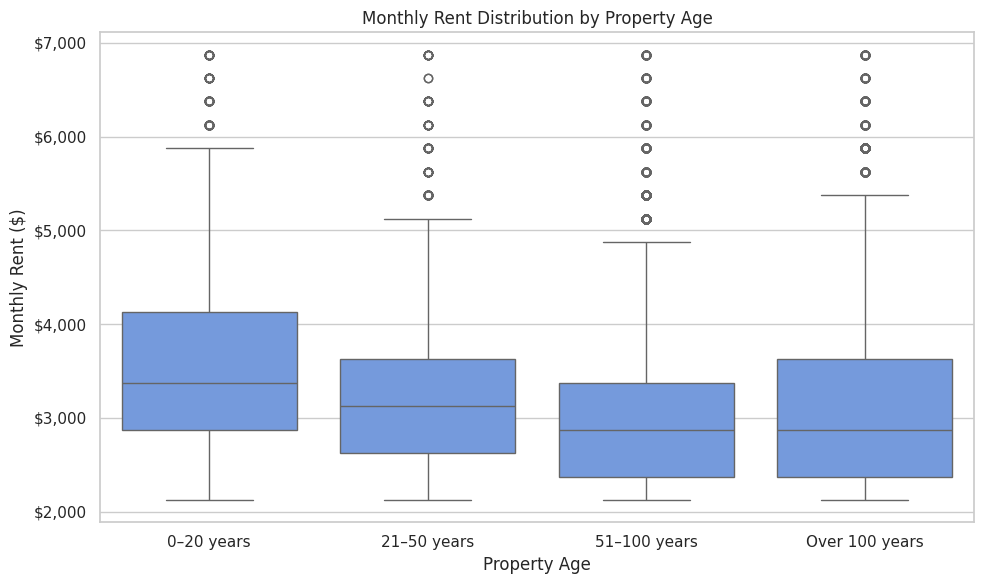

In [104]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=age_data,
    x="property_age_group",
    y="rent_midpoint",
    color="cornflowerblue"
)

plt.title("Monthly Rent Distribution by Property Age")
plt.xlabel("Property Age")
plt.ylabel("Monthly Rent ($)")
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

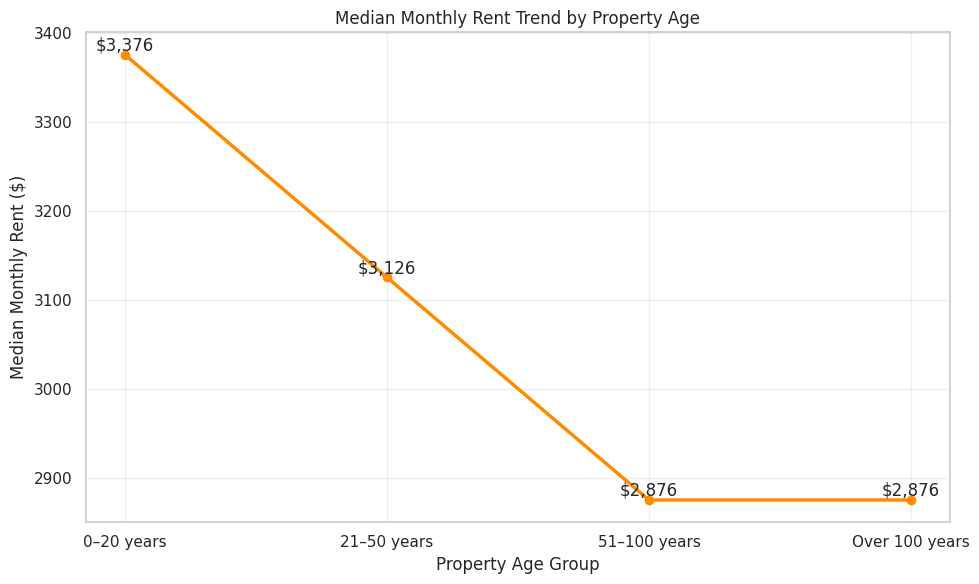

In [96]:
# Calculate median rent by property-age group
age_summary = (
    age_data
    .groupby("property_age_group", observed=False)["rent_midpoint"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    age_summary["property_age_group"].astype(str),
    age_summary["rent_midpoint"],
    marker="o",
    linewidth=2.5,
    color="darkorange"
)

# Add exact values
for x, y in zip(
    age_summary["property_age_group"].astype(str),
    age_summary["rent_midpoint"]
):
    plt.text(
        x, y,
        f"${y:,.0f}",
        ha="center",
        va="bottom"
    )

plt.title("Median Monthly Rent Trend by Property Age")
plt.xlabel("Property Age Group")
plt.ylabel("Median Monthly Rent ($)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [97]:
analysis_data = eda_final[
    ["property_age", "rent_midpoint"]
].copy()

print("Rows before cleaning:", len(analysis_data))
print("\nMissing values:")
print(analysis_data.isna().sum())

Rows before cleaning: 49395

Missing values:
property_age     1460
rent_midpoint       0
dtype: int64


In [98]:
analysis_data = analysis_data.dropna(
    subset=["property_age", "rent_midpoint"]
)

print("Rows after removing nulls:", len(analysis_data))

Rows after removing nulls: 47935


In [99]:
def get_iqr_limits(column):
    q1 = analysis_data[column].quantile(0.25)
    q3 = analysis_data[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

age_lower, age_upper = get_iqr_limits("property_age")
rent_lower, rent_upper = get_iqr_limits("rent_midpoint")

print("Property age limits:", age_lower, age_upper)
print("Rent limits:", rent_lower, rent_upper)

Property age limits: -22.0 194.0
Rent limits: -624.5 5375.5


In [100]:
analysis_clean = analysis_data[
    (analysis_data["property_age"] >= age_lower) &
    (analysis_data["property_age"] <= age_upper) &
    (analysis_data["rent_midpoint"] >= rent_lower) &
    (analysis_data["rent_midpoint"] <= rent_upper)
].copy()

print("Rows after removing outliers:", len(analysis_clean))
print("Rows removed:", len(analysis_data) - len(analysis_clean))

Rows after removing outliers: 46922
Rows removed: 1013


In [101]:
comparison = pd.DataFrame({
    "Before": [
        len(analysis_data),
        analysis_data["property_age"].median(),
        analysis_data["rent_midpoint"].median()
    ],
    "After": [
        len(analysis_clean),
        analysis_clean["property_age"].median(),
        analysis_clean["rent_midpoint"].median()
    ]
}, index=[
    "Number of records",
    "Median property age",
    "Median monthly rent"
])

comparison

,Before,After
Number of records,47935.0,46922.0
Median property age,97.0,97.0
Median monthly rent,2375.5,2375.5


In [102]:
print("Original dataset:", eda_final.shape)
print("Analysis dataset:", analysis_clean.shape)

Original dataset: (49395, 19)
Analysis dataset: (46922, 2)


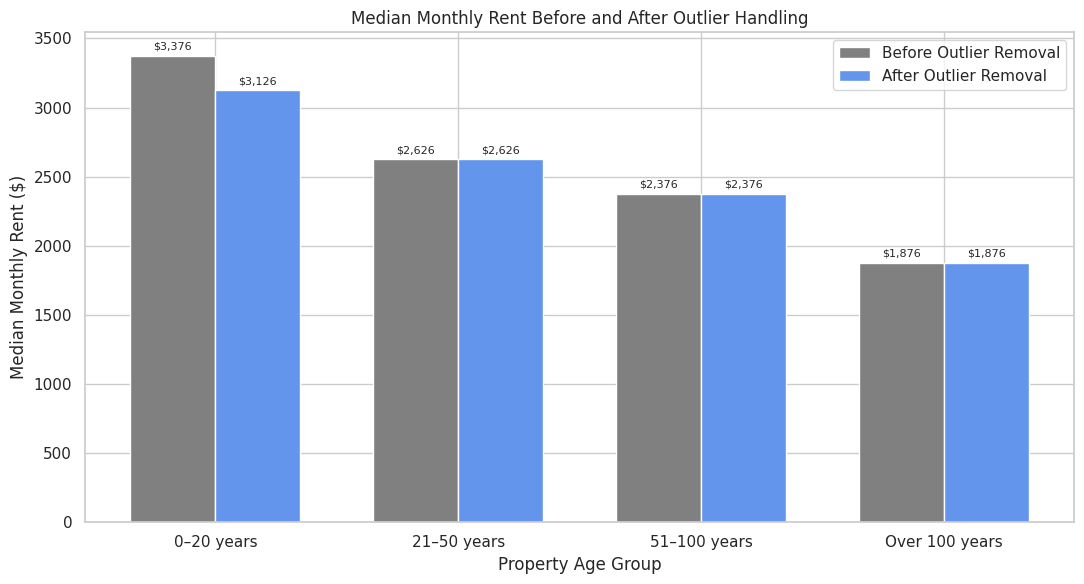

In [105]:
age_groups = [
    "0–20 years",
    "21–50 years",
    "51–100 years",
    "Over 100 years"
]

# Before cleaning: remove only nulls
before_data = eda_final[
    ["property_age", "rent_midpoint"]
].dropna().copy()

before_data["property_age_group"] = pd.cut(
    before_data["property_age"],
    bins=[0, 20, 50, 100, float("inf")],
    labels=age_groups,
    include_lowest=True
)

# Median rent before outlier removal
before_summary = (
    before_data
    .groupby("property_age_group", observed=False)["rent_midpoint"]
    .median()
    .reindex(age_groups)
)

# Median rent after null and outlier removal
after_summary = (
    analysis_clean
    .groupby("property_age_group", observed=False)["rent_midpoint"]
    .median()
    .reindex(age_groups)
)

# Create comparison chart
x = np.arange(len(age_groups))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width / 2,
    before_summary.values,
    width,
    label="Before Outlier Removal",
    color="gray"
)

bars2 = ax.bar(
    x + width / 2,
    after_summary.values,
    width,
    label="After Outlier Removal",
    color="cornflowerblue"
)

# Add labels
ax.bar_label(
    bars1,
    labels=[f"${v:,.0f}" if not pd.isna(v) else "N/A"
            for v in before_summary.values],
    padding=3,
    fontsize=8
)

ax.bar_label(
    bars2,
    labels=[f"${v:,.0f}" if not pd.isna(v) else "N/A"
            for v in after_summary.values],
    padding=3,
    fontsize=8
)

ax.set_title("Median Monthly Rent Before and After Outlier Handling")
ax.set_xlabel("Property Age Group")
ax.set_ylabel("Median Monthly Rent ($)")
ax.set_xticks(x)
ax.set_xticklabels(age_groups)
ax.legend()

plt.tight_layout()
plt.show()

# Bivariate Analysis — Overall Conclusion

The bivariate analysis shows that monthly rent is related to housing size and location. Larger square footage and more bedrooms are generally associated with higher rent, while neighborhood comparisons show substantial geographic differences. These findings identify square footage, bedroom category, and neighborhood as important variables for the next stage of the project. The relationships are associations, so they should not be interpreted as proof that one variable directly causes rent to change.

## Optional — Save the cleaned analysis dataset

In [ ]:
eda_final.to_csv('Rent_Board_Housing_Cleaned_For_Tableau.csv', index=False)
print('Cleaned Tableau file saved.')

Cleaned Tableau file saved.
